# Tutorial 1.2: Time-series data quality and benchmark forecasting

## 1. Overview and learning outcomes

This tutorial accompanies Lecture 1.2 of **BENV0169 Data Analytics for Sustainable Buildings**. We use hourly aggregate electricity demand to study missing data, simple forecasts and forecast evaluation.

By the end of the tutorial, you should be able to:

- inspect a time index and distinguish absent timestamps from stored `NaN` values;
- compare imputation methods using observations that we hide artificially;
- construct day-ahead, rolling-origin and fixed week-ahead benchmark forecasts;
- calculate RMSE, MAPE and MASE with suitable checks;
- compare forecasts without using information that was unavailable at the forecast origin.

### Indicative schedule

| Activity | Time |
|---|---:|
| Setup and time-index checks | 10 minutes |
| Imputation experiment | 25 minutes |
| Benchmark methods and metrics | 20 minutes |
| Day-ahead, rolling and fixed-week experiments | 30 minutes |
| Interpretation | 5 minutes |

## 2. Setup and data loading

The data come from the load-forecasting track of GEFCom2012. Columns `Z1` to `Z20` contain demand for twenty zones. `Z21` is their total demand. Demand is measured in MW.

**Reference**

Hong, T., Pinson, P. and Fan, S. (2014) ‘Global Energy Forecasting Competition 2012’, *International Journal of Forecasting*, 30(2), pp. 357–363. [https://doi.org/10.1016/j.ijforecast.2013.07.001](https://doi.org/10.1016/j.ijforecast.2013.07.001)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.constrained_layout.use"] = True
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 4)


In [2]:
DATA_PATH = Path("data") / "tutorial_1_2" / "load_data_full.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Launch Jupyter from the repository root."
    )

load_data = pd.read_csv(DATA_PATH, index_col=0, parse_dates=[0])
load_data.index.name = "timestamp"
load_data = load_data.sort_index()

if not isinstance(load_data.index, pd.DatetimeIndex):
    raise TypeError("The first CSV column must parse as a DatetimeIndex.")
if "Z21" not in load_data.columns:
    raise KeyError("Expected the aggregate load column 'Z21'.")

print(f"Loaded {len(load_data):,} rows and {load_data.shape[1]} demand columns.")
load_data.head(3)


Loaded 24,936 rows and 21 demand columns.


,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,...,Z12,Z13,Z14,Z15,Z16,Z17,Z18,Z19,Z20,Z21
timestamp,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:00:00,13.599,117.054,126.301,484.0,6.480,123.533,126.301,3.120,81.459,22.208,...,112.730,17.971,19.960,57.339,25.121,27.083,173.648,65.506,67.813,1758.182
2005-01-01 01:00:00,13.178,112.791,121.702,443.0,6.194,118.986,121.702,2.918,81.354,21.227,...,105.182,16.891,19.028,54.627,23.584,26.346,166.863,61.806,64.936,1664.333
2005-01-01 02:00:00,12.690,109.221,117.850,406.0,5.944,115.165,117.850,2.840,80.955,20.481,...,99.006,16.001,18.249,52.769,22.536,25.680,162.338,58.759,63.222,1585.701


## 3. Time-index quality

### Worked example: inspect the time index

Before analysing a time series, check its dates, sampling interval, duplicate timestamps and missing data. The supplied code reports:

- the start and end timestamps;
- the usual time between observations;
- duplicate timestamps;
- timestamps missing from the expected hourly sequence;
- stored `NaN` values.

Run the cells and inspect the summary and missing-block table. Identify absent timestamps **before** reindexing the data onto the complete hourly time grid. You do not need to complete any code in this section.

In [3]:
def summarise_time_index(data, expected_frequency="h"):
    '''Return key time-index and explicit-missingness checks.'''
    if not isinstance(data.index, pd.DatetimeIndex):
        raise TypeError("data must have a DatetimeIndex.")
    if data.empty:
        raise ValueError("data must contain at least one row.")

    time_differences = data.index.to_series().diff().dropna()
    nominal_interval = time_differences.mode().iloc[0]
    expected_index = pd.date_range(
        start=data.index.min(),
        end=data.index.max(),
        freq=expected_frequency,
    )
    missing_timestamps = expected_index.difference(data.index)

    return {
        "start": data.index.min(),
        "end": data.index.max(),
        "nominal_interval": nominal_interval,
        "duplicate_timestamps": int(data.index.duplicated().sum()),
        "missing_timestamps": missing_timestamps,
        "rows_with_nan": int(data.isna().any(axis=1).sum()),
        "nan_cells": int(data.isna().sum().sum()),
    }


In [4]:
time_quality = summarise_time_index(load_data)

print("Data-quality summary")
print(f"  Coverage: {time_quality['start']} to {time_quality['end']}")
print(f"  Nominal interval: {time_quality['nominal_interval']}")
print(f"  Duplicate timestamps: {time_quality['duplicate_timestamps']:,}")
print(f"  Missing timestamps: {len(time_quality['missing_timestamps']):,}")
print(f"  Stored rows containing NaN: {time_quality['rows_with_nan']:,}")
print(f"  Explicit NaN cells: {time_quality['nan_cells']:,}")


Data-quality summary
  Coverage: 2005-01-01 00:00:00 to 2007-12-31 23:00:00
  Nominal interval: 0 days 01:00:00
  Duplicate timestamps: 0
  Missing timestamps: 1,344
  Stored rows containing NaN: 0
  Explicit NaN cells: 0


In [5]:
def consecutive_timestamp_blocks(timestamps, frequency="h"):
    '''Summarise a DatetimeIndex as consecutive blocks.'''
    timestamps = pd.DatetimeIndex(timestamps).sort_values()
    if timestamps.empty:
        return pd.DataFrame(columns=["start", "end", "hours"])

    step = pd.to_timedelta(1, unit=frequency)
    block_starts = [timestamps[0]]
    block_ends = []

    for previous, current in zip(timestamps[:-1], timestamps[1:]):
        if current - previous != step:
            block_ends.append(previous)
            block_starts.append(current)
    block_ends.append(timestamps[-1])

    blocks = pd.DataFrame({"start": block_starts, "end": block_ends})
    blocks["hours"] = (
        (blocks["end"] - blocks["start"]) / pd.Timedelta(hours=1) + 1
    ).astype(int)
    return blocks


missing_blocks = consecutive_timestamp_blocks(time_quality["missing_timestamps"])
missing_blocks


,start,end,hours
0,2005-03-06,2005-03-12 23:00:00,168
1,2005-06-20,2005-06-26 23:00:00,168
2,2005-09-10,2005-09-16 23:00:00,168
3,2005-12-25,2005-12-31 23:00:00,168
4,2006-02-13,2006-02-19 23:00:00,168
5,2006-05-25,2006-05-31 23:00:00,168
6,2006-08-02,2006-08-08 23:00:00,168
7,2006-11-22,2006-11-28 23:00:00,168


In [6]:
if time_quality["duplicate_timestamps"] != 0:
    raise ValueError("Resolve duplicate timestamps before reindexing.")

full_hourly_index = pd.date_range(
    start=load_data.index.min(),
    end=load_data.index.max(),
    freq="h",
    name="timestamp",
)
hourly_load_data = load_data.reindex(full_hourly_index)

newly_created_missing_rows = hourly_load_data.index.difference(load_data.index)
print(f"Rows after hourly reindexing: {len(hourly_load_data):,}")
print(f"Rows inserted by reindexing: {len(newly_created_missing_rows):,}")


Rows after hourly reindexing: 26,280
Rows inserted by reindexing: 1,344


**Interpretation.** An absent timestamp has no row in the original data. We find it by comparing the observed timestamps with the complete hourly sequence. A stored `NaN` already has a row, but its value is missing. Reindexing adds rows for absent timestamps and places `NaN` in them. Count the two types separately before reindexing.

### Seasonal patterns in a complete year

The 2007 data have a complete hourly index. The first plot shows two weeks of `Z21`. The other plots show mean demand by hour of day and hour of week. Use them to identify daily seasonality, $m=24$, and weekly seasonality, $m=168$.

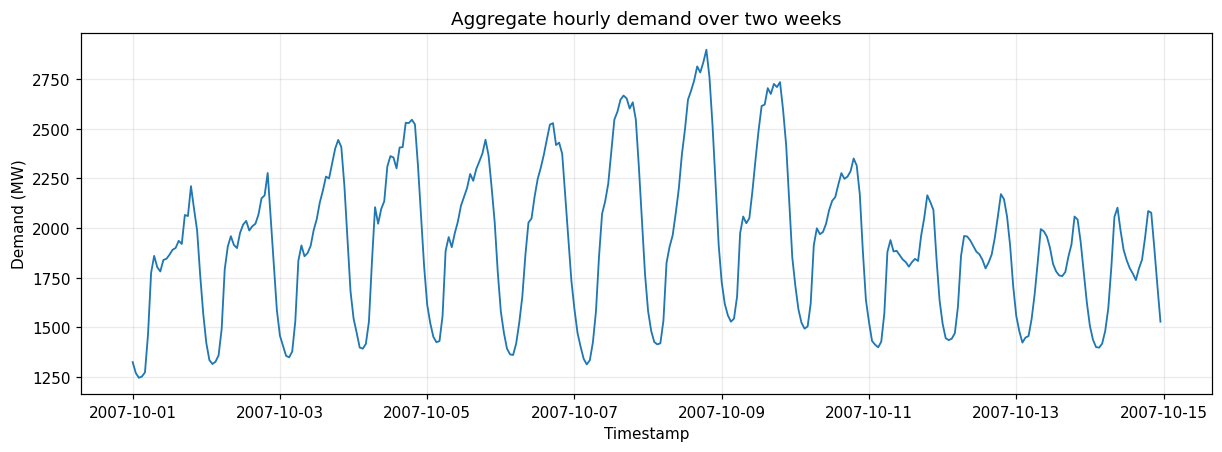

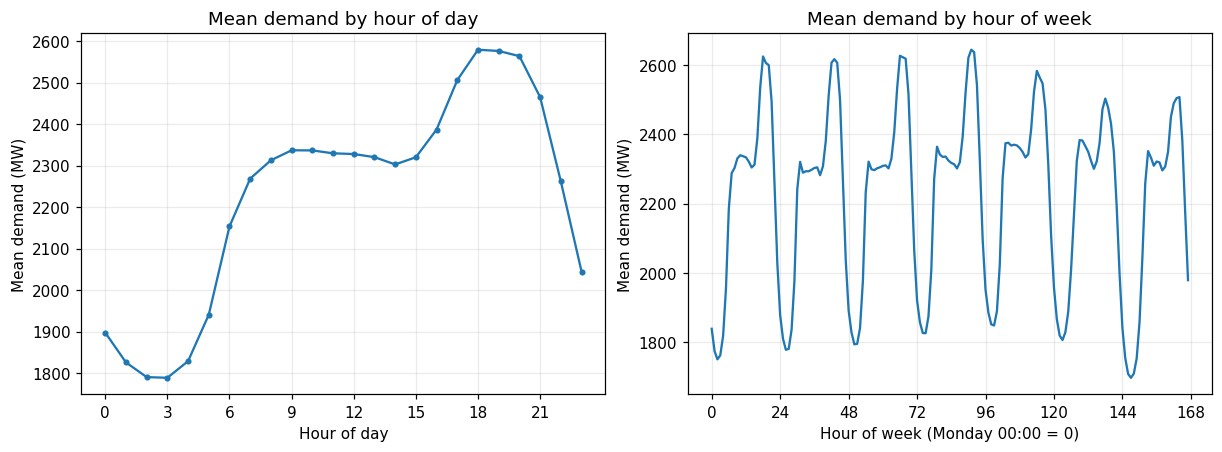

In [7]:
aggregate_load_2007 = hourly_load_data.loc["2007", "Z21"].copy()
expected_2007_index = pd.date_range(
    "2007-01-01 00:00", "2007-12-31 23:00", freq="h", name="timestamp"
)

if not aggregate_load_2007.index.equals(expected_2007_index):
    raise ValueError("The selected 2007 index is not complete and hourly.")
if aggregate_load_2007.isna().any():
    raise ValueError("The selected 2007 aggregate series contains missing values.")

two_weeks = aggregate_load_2007.loc["2007-10-01":"2007-10-14 23:00"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(two_weeks.index, two_weeks, color="tab:blue", linewidth=1.2)
ax.set(
    title="Aggregate hourly demand over two weeks",
    xlabel="Timestamp",
    ylabel="Demand (MW)",
)
ax.grid(alpha=0.25)
plt.show()

mean_by_hour = aggregate_load_2007.groupby(aggregate_load_2007.index.hour).mean()
hour_of_week = aggregate_load_2007.index.dayofweek * 24 + aggregate_load_2007.index.hour
mean_by_hour_of_week = aggregate_load_2007.groupby(hour_of_week).mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mean_by_hour.index, mean_by_hour, marker="o", markersize=3)
axes[0].set(
    title="Mean demand by hour of day",
    xlabel="Hour of day",
    ylabel="Mean demand (MW)",
)
axes[0].set_xticks(range(0, 24, 3))
axes[0].grid(alpha=0.25)

axes[1].plot(mean_by_hour_of_week.index, mean_by_hour_of_week)
axes[1].set(
    title="Mean demand by hour of week",
    xlabel="Hour of week (Monday 00:00 = 0)",
    ylabel="Mean demand (MW)",
)
axes[1].set_xticks(range(0, 169, 24))
axes[1].grid(alpha=0.25)
plt.show()


## 4. Imputation experiment

The long gaps in 2005 and 2006 cannot be used to test imputation because their true values are unknown. Instead, we select a complete period from 2007 and deliberately hide known observations.

We create:

- one missing hour;
- one six-hour gap;
- one 24-hour gap.

The original observations are stored in `imputation_truth`. The series with hidden values is `corrupted_load`. Pass only `corrupted_load` to the imputation methods.

In [8]:
imputation_truth = aggregate_load_2007.loc[
    "2007-09-23 00:00":"2007-10-28 23:00"
].copy()

artificial_gaps = {
    "Isolated hour": pd.date_range("2007-10-02 14:00", periods=1, freq="h"),
    "Six-hour gap": pd.date_range("2007-10-10 09:00", periods=6, freq="h"),
    "24-hour gap": pd.date_range("2007-10-20 00:00", periods=24, freq="h"),
}
masked_timestamps = pd.DatetimeIndex(
    sorted(timestamp for gap in artificial_gaps.values() for timestamp in gap)
)

if not masked_timestamps.isin(imputation_truth.index).all():
    raise ValueError("Every masked timestamp must lie inside the complete interval.")
if imputation_truth.loc[masked_timestamps].isna().any():
    raise ValueError("Ground truth must be observed at every masked timestamp.")

corrupted_load = imputation_truth.copy()
corrupted_load.loc[masked_timestamps] = np.nan

print(f"Artificially masked observations: {corrupted_load.isna().sum()}")
for gap_name, gap_index in artificial_gaps.items():
    print(f"  {gap_name}: {gap_index[0]} to {gap_index[-1]} ({len(gap_index)} hour(s))")


Artificially masked observations: 31
  Isolated hour: 2007-10-02 14:00:00 to 2007-10-02 14:00:00 (1 hour(s))
  Six-hour gap: 2007-10-10 09:00:00 to 2007-10-10 14:00:00 (6 hour(s))
  24-hour gap: 2007-10-20 00:00:00 to 2007-10-20 23:00:00 (24 hour(s))


### Inspect the artificial gaps

Look at each gap before choosing an imputation method. Consider:

- how quickly demand changes around the gap;
- whether the daily pattern repeats;
- how much information remains when the gap becomes longer.

The shaded areas show the observations that must be reconstructed.

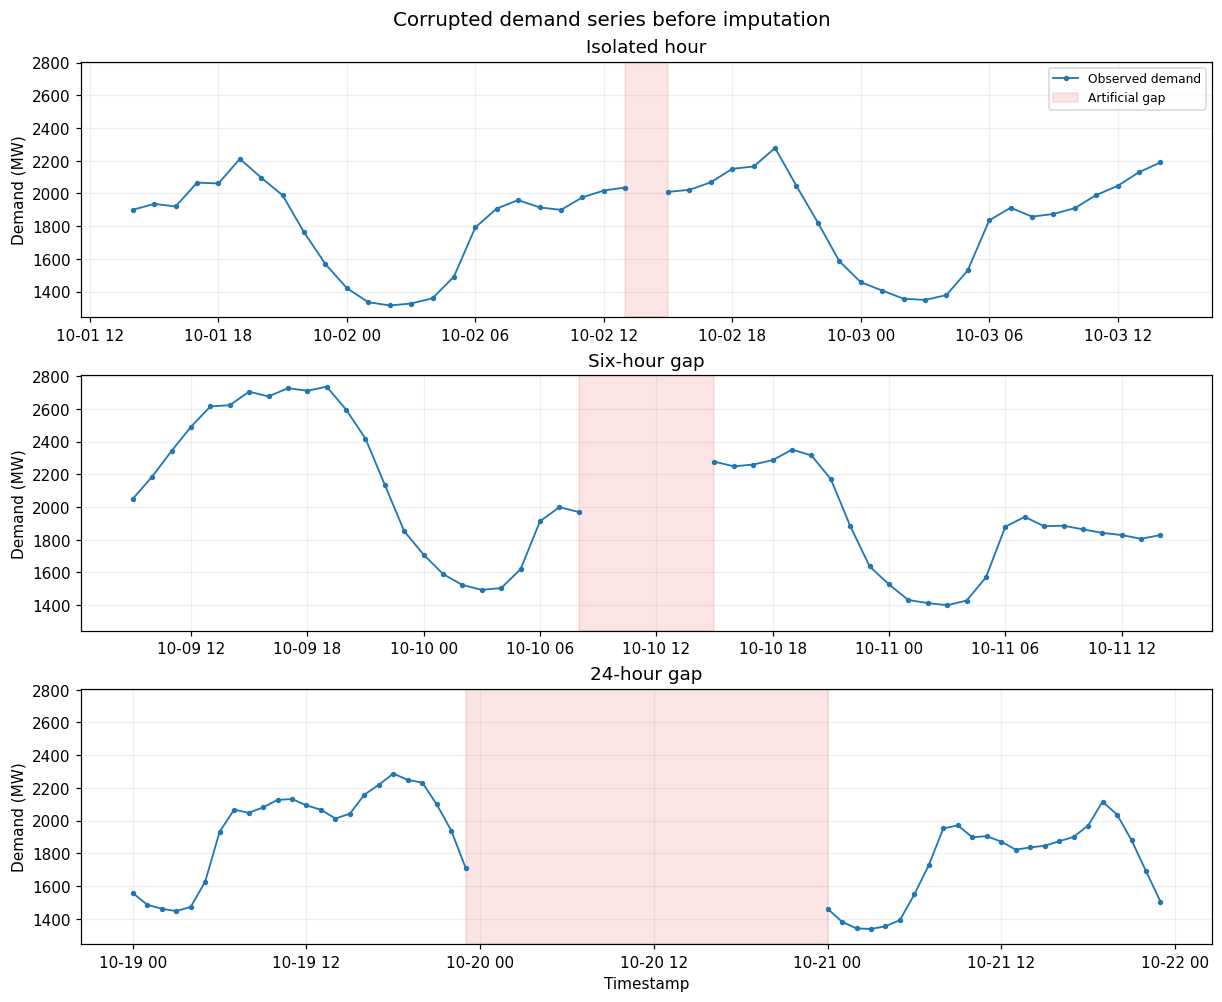

In [9]:
fig, axes = plt.subplots(
    len(artificial_gaps),
    1,
    figsize=(11, 9),
    sharey=True,
)

for ax, (gap_name, gap_index) in zip(axes, artificial_gaps.items()):
    window_start = gap_index[0] - pd.Timedelta(hours=24)
    window_end = gap_index[-1] + pd.Timedelta(hours=24)
    visible_data = corrupted_load.loc[window_start:window_end]

    ax.plot(
        visible_data.index,
        visible_data,
        color="tab:blue",
        marker="o",
        markersize=2.5,
        linewidth=1.2,
        label="Observed demand",
    )
    ax.axvspan(
        gap_index[0] - pd.Timedelta(hours=1),
        gap_index[-1] + pd.Timedelta(hours=1),
        color="tab:red",
        alpha=0.12,
        label="Artificial gap",
    )
    ax.set_title(gap_name)
    ax.set_ylabel("Demand (MW)")
    ax.grid(alpha=0.2)

axes[0].legend(fontsize=8)
axes[-1].set_xlabel("Timestamp")
fig.suptitle("Corrupted demand series before imputation", fontsize=13)
plt.show()


### Task 1: implement the imputation methods

Implement four methods:

1. forward fill;
2. the mean of the observed values in the selected period;
3. time-based linear interpolation;
4. the observation from the same hour one week earlier, $m=168$.

Each function must return a complete `Series` with the same index. It must not change observed values. Do not use `imputation_truth` inside an imputation function.

In [10]:
def forward_fill_imputation(series):
    '''Fill each gap using the last observed value.'''
    reconstructed = series.ffill()
    if reconstructed.isna().any():
        raise ValueError("Forward fill could not fill a gap at the start of the series.")
    return reconstructed


def observed_mean_imputation(series):
    '''Fill gaps with the mean of all observed values in this interval.'''
    observed_mean = series.mean(skipna=True)
    if pd.isna(observed_mean):
        raise ValueError("The series contains no observed values.")
    return series.fillna(observed_mean)


def linear_interpolation_imputation(series):
    '''Fill internal gaps by linear interpolation in time.'''
    reconstructed = series.interpolate(method="time")
    if reconstructed.isna().any():
        raise ValueError("Linear interpolation left missing values at an endpoint.")
    return reconstructed


def previous_week_imputation(series, period=168):
    '''Replace each missing value with the observation one week earlier.'''
    if not isinstance(period, int) or period <= 0:
        raise ValueError("period must be a positive integer number of hours.")

    reconstructed = series.copy()
    for timestamp in series.index[series.isna()]:
        source_timestamp = timestamp - pd.Timedelta(hours=period)
        if source_timestamp not in series.index:
            raise ValueError(f"No preceding-week value for {timestamp}.")
        source_value = series.loc[source_timestamp]
        if pd.isna(source_value):
            raise ValueError(f"The preceding-week value for {timestamp} is missing.")
        reconstructed.loc[timestamp] = source_value
    return reconstructed


In [11]:
imputed_series = {
    "Forward fill": forward_fill_imputation(corrupted_load),
    "Observed mean": observed_mean_imputation(corrupted_load),
    "Linear interpolation": linear_interpolation_imputation(corrupted_load),
    "Previous week": previous_week_imputation(corrupted_load, period=168),
}

observed_mask = corrupted_load.notna()
for method_name, reconstructed in imputed_series.items():
    if not reconstructed.index.equals(corrupted_load.index):
        raise ValueError(f"{method_name} changed the index.")
    if not reconstructed.loc[observed_mask].equals(corrupted_load.loc[observed_mask]):
        raise ValueError(f"{method_name} changed observations that were not masked.")


### Task 2: evaluate reconstruction accuracy

Complete `score_imputations`. Calculate RMSE and MAE only at the timestamps that were hidden artificially. A lower score means that the reconstructed values are closer to the true observations.

In [12]:
def score_imputations(truth, missing_index, reconstructions):
    '''Return RMSE and MAE at deliberately masked timestamps only.'''
    actual = truth.loc[missing_index].to_numpy(dtype=float)
    rows = []

    for method_name, reconstructed in reconstructions.items():
        if not truth.index.equals(reconstructed.index):
            raise ValueError(f"Index mismatch for {method_name}.")
        estimate = reconstructed.loc[missing_index].to_numpy(dtype=float)
        errors = actual - estimate
        rows.append(
            {
                "Method": method_name,
                "RMSE (MW)": np.sqrt(np.mean(errors ** 2)),
                "MAE (MW)": np.mean(np.abs(errors)),
            }
        )

    return pd.DataFrame(rows).set_index("Method").sort_values("RMSE (MW)")


In [13]:
imputation_scores = score_imputations(
    imputation_truth,
    masked_timestamps,
    imputed_series,
)
imputation_scores.round(2)


,RMSE (MW),MAE (MW)
Method,,
Previous week,129.44,86.65
Forward fill,211.31,189.98
Observed mean,267.18,191.45
Linear interpolation,280.97,237.07


### Visual comparison

Compare the methods for each gap length. Look for missed peaks, flattened profiles and abrupt changes introduced by the reconstruction.

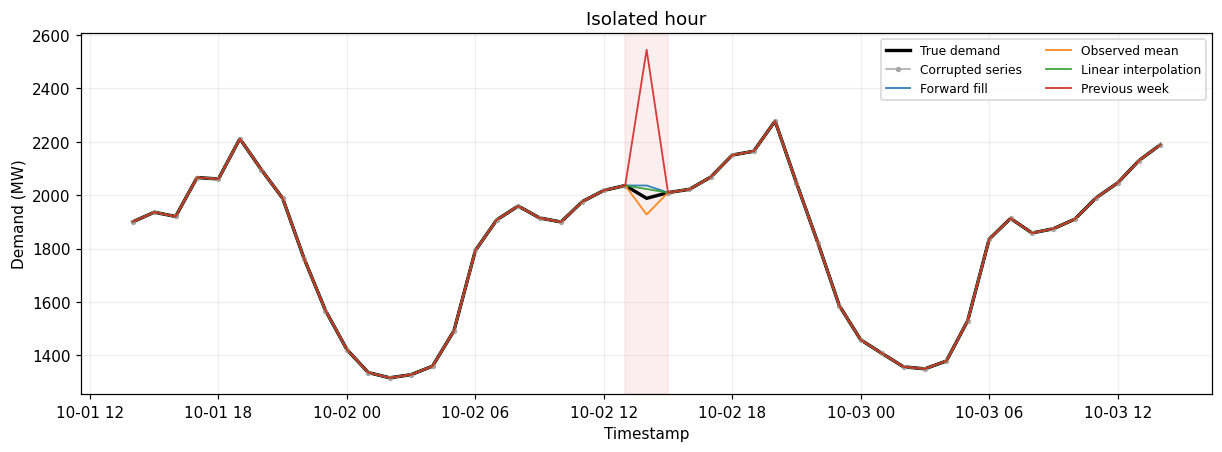

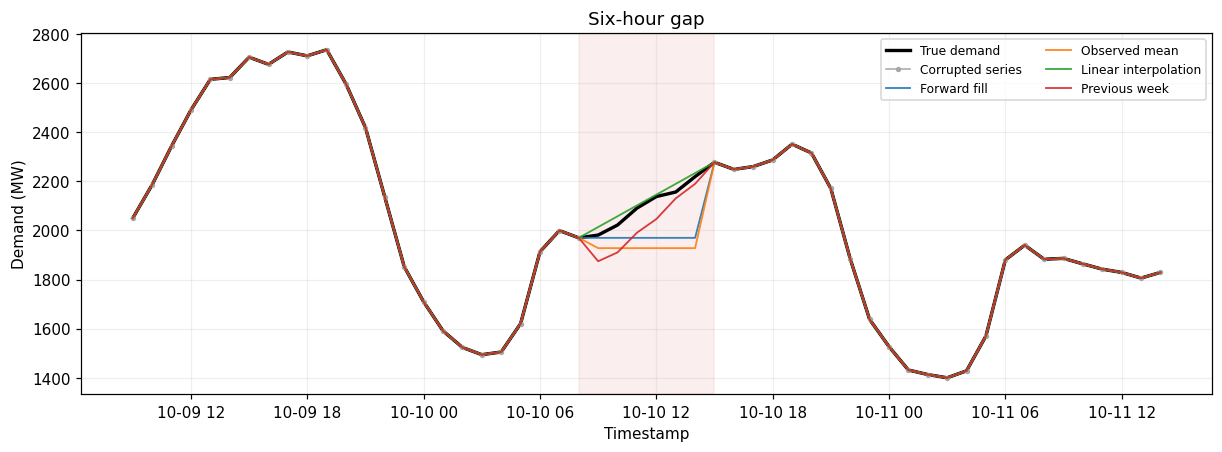

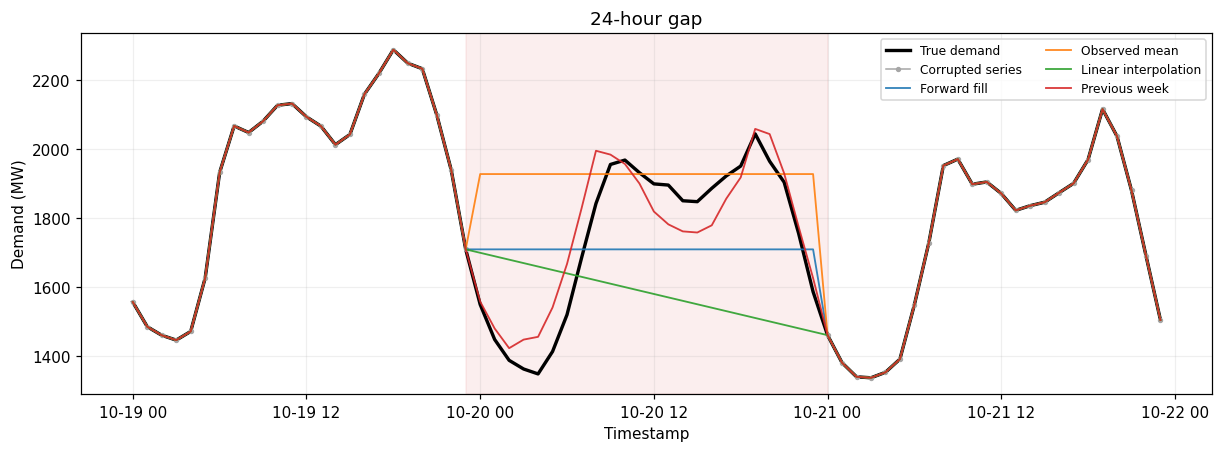

In [14]:
def plot_imputation_window(gap_name, gap_index, truth, corrupted, reconstructions):
    '''Plot 24 hours of context on either side of one artificial gap.'''
    window_start = gap_index[0] - pd.Timedelta(hours=24)
    window_end = gap_index[-1] + pd.Timedelta(hours=24)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(
        truth.loc[window_start:window_end],
        color="black",
        linewidth=2.2,
        label="True demand",
    )
    ax.plot(
        corrupted.loc[window_start:window_end],
        color="0.65",
        marker="o",
        markersize=2.5,
        linewidth=1,
        label="Corrupted series",
    )
    for method_name, reconstructed in reconstructions.items():
        ax.plot(
            reconstructed.loc[window_start:window_end],
            linewidth=1.2,
            alpha=0.9,
            label=method_name,
        )

    ax.axvspan(
        gap_index[0] - pd.Timedelta(hours=1),
        gap_index[-1] + pd.Timedelta(hours=1),
        color="tab:red",
        alpha=0.08,
        )
    ax.set(title=gap_name, xlabel="Timestamp", ylabel="Demand (MW)")
    ax.grid(alpha=0.2)
    ax.legend(ncol=2, fontsize=8)
    plt.show()


for gap_name, gap_index in artificial_gaps.items():
    plot_imputation_window(
        gap_name,
        gap_index,
        imputation_truth,
        corrupted_load,
        imputed_series,
    )


### Optional extension: average the surrounding weeks

Compare previous-week replacement with the mean of the matching hours in the previous and following weeks. This method is suitable only for retrospective cleaning because it uses observations from after the gap.

In [15]:
def surrounding_weeks_average_imputation(series, period=168):
    '''Average matching hours in the preceding and following weeks.'''
    reconstructed = series.copy()
    for timestamp in series.index[series.isna()]:
        previous_timestamp = timestamp - pd.Timedelta(hours=period)
        following_timestamp = timestamp + pd.Timedelta(hours=period)
        if previous_timestamp not in series.index or following_timestamp not in series.index:
            raise ValueError(f"Surrounding-week values are unavailable for {timestamp}.")
        values = series.loc[[previous_timestamp, following_timestamp]]
        if values.isna().any():
            raise ValueError(f"A surrounding-week value is missing for {timestamp}.")
        reconstructed.loc[timestamp] = values.mean()
    return reconstructed


optional_imputation = surrounding_weeks_average_imputation(corrupted_load)
optional_scores = score_imputations(
    imputation_truth,
    masked_timestamps,
    {"Previous week": imputed_series["Previous week"],
     "Surrounding-week average": optional_imputation},
)
optional_scores.round(2)


,RMSE (MW),MAE (MW)
Method,,
Previous week,129.44,86.65
Surrounding-week average,133.10,83.25


## 5. Forecasting experiments

We now return to the original complete 2007 series. The artificial gaps used above do not affect the forecasting exercises.

We use the same benchmark methods in three settings:

1. one 24-hour day-ahead forecast from a single origin;
2. rolling day-ahead forecasts, updated every 24 hours over the full October–December test period and plotted for one week;
3. one 168-hour forecast for the full example week from a single fixed origin.

Comparing the rolling and fixed forecasts for the same week shows the effect of updating the forecast when new observations become available.

In [16]:
# Fixed-origin experiments and the one-week illustration
training_load = aggregate_load_2007.loc[
    "2007-01-01 00:00":"2007-12-16 23:00"
].copy()
test_week = aggregate_load_2007.loc[
    "2007-12-17 00:00":"2007-12-23 23:00"
].copy()
initial_forecast_origin = pd.Timestamp("2007-12-16 23:00")
day_ahead_actual = test_week.iloc[:24].copy()

# Longer test set for the rolling day-ahead experiment
rolling_training_load = aggregate_load_2007.loc[
    "2007-01-01 00:00":"2007-09-30 23:00"
].copy()
rolling_test_load = aggregate_load_2007.loc[
    "2007-10-01 00:00":"2007-12-31 23:00"
].copy()

expected_test_week_index = pd.date_range(
    "2007-12-17 00:00",
    "2007-12-23 23:00",
    freq="h",
    name="timestamp",
)
expected_rolling_test_index = pd.date_range(
    "2007-10-01 00:00",
    "2007-12-31 23:00",
    freq="h",
    name="timestamp",
)

if training_load.index[-1] != initial_forecast_origin:
    raise ValueError("The fixed-origin training set must end at the forecast origin.")
if len(test_week) != 168 or not test_week.index.equals(expected_test_week_index):
    raise ValueError("The illustration week must contain 168 consecutive hours.")
if not rolling_test_load.index.equals(expected_rolling_test_index):
    raise ValueError("The rolling test set must contain every hour in Q4 2007.")
if len(rolling_test_load) % 24 != 0:
    raise ValueError("The rolling test set must contain complete days.")
if len(day_ahead_actual) != 24:
    raise ValueError("The first day-ahead evaluation window must contain 24 hours.")
if any(
    series.isna().any()
    for series in (
        training_load,
        test_week,
        rolling_training_load,
        rolling_test_load,
    )
):
    raise ValueError("All forecasting intervals must be complete.")

print(f"Fixed-origin training observations: {len(training_load):,}")
print(f"Fixed forecast origin: {initial_forecast_origin}")
print(f"Illustration week: {test_week.index[0]} to {test_week.index[-1]}")
print(
    f"Rolling test set: {rolling_test_load.index[0]} to "
    f"{rolling_test_load.index[-1]} ({len(rolling_test_load) // 24} days)"
)


Fixed-origin training observations: 8,400
Fixed forecast origin: 2007-12-16 23:00:00
Illustration week: 2007-12-17 00:00:00 to 2007-12-23 23:00:00
Rolling test set: 2007-10-01 00:00:00 to 2007-12-31 23:00:00 (92 days)


### One-step-ahead versus recursive multi-step forecasts

The main difference is the information available when each prediction is made.

- A **one-step-ahead** forecast predicts the next hour. After the actual value is observed, that value is used to make the next prediction: $\hat{y}_{t\mid t-1}=y_{t-1}$.
- A **recursive multi-step** forecast predicts several future hours from one origin. Future actual values are unavailable, so each new step uses the previous prediction: $\hat{y}_{t+h\mid t}=\hat{y}_{t+h-1\mid t}$.

With persistence, every recursive prediction equals the last observation available at the origin. One-step forecasts often look much better because they receive a new observation every hour. They are useful for diagnosis, but they are not a substitute for a 24- or 168-hour forecast made from one origin.

The same idea appears in the later building-model tutorials. A one-step thermal prediction is reset using each measured indoor temperature. A recursive multi-step simulation uses its own previous predictions; this is called a **free rollout**.

,RMSE [MW],New actual observations used after origin
One-step persistence,160.2,167
Recursive multi-step persistence,416.4,0


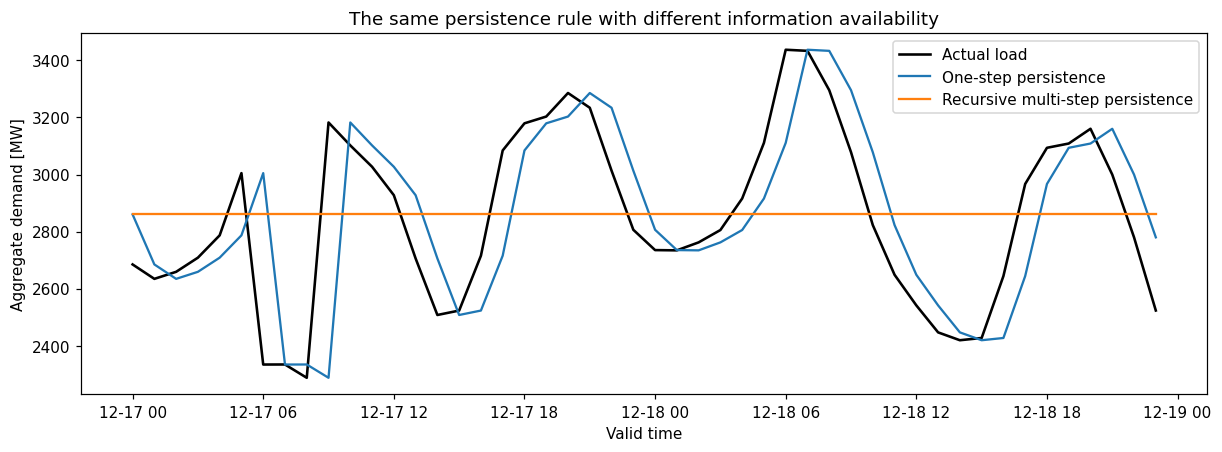

In [17]:
# The same persistence rule under two information patterns.
comparison_index = test_week.index

# At each timestamp, the preceding actual load has become available.
one_step_persistence = (
    aggregate_load_2007.shift(1)
    .loc[comparison_index]
    .rename("One-step persistence")
)

# From the fixed origin, no test-week observations are available. Feeding the
# persistence prediction back recursively repeats the final training value.
recursive_persistence = pd.Series(
    training_load.iloc[-1],
    index=comparison_index,
    name="Recursive multi-step persistence",
)

information_comparison = pd.DataFrame(
    {
        "RMSE [MW]": {
            "One-step persistence": np.sqrt(
                np.mean((test_week - one_step_persistence) ** 2)
            ),
            "Recursive multi-step persistence": np.sqrt(
                np.mean((test_week - recursive_persistence) ** 2)
            ),
        },
        "New actual observations used after origin": {
            "One-step persistence": len(test_week) - 1,
            "Recursive multi-step persistence": 0,
        },
    }
)
display(information_comparison.round(1))

comparison_plot_index = comparison_index[:48]
plt.figure(figsize=(11, 4))
plt.plot(
    comparison_plot_index,
    test_week.loc[comparison_plot_index],
    color="black",
    linewidth=1.7,
    label="Actual load",
)
plt.plot(
    comparison_plot_index,
    one_step_persistence.loc[comparison_plot_index],
    label="One-step persistence",
)
plt.plot(
    comparison_plot_index,
    recursive_persistence.loc[comparison_plot_index],
    label="Recursive multi-step persistence",
)
plt.ylabel("Aggregate demand [MW]")
plt.xlabel("Valid time")
plt.title("The same persistence rule with different information availability")
plt.legend()
plt.show()


### Fixed and rolling forecast origins

In the rolling experiment, each 24-hour forecast has a new origin. After one day, the actual observations from that day become available and are added to the history. The next forecast then uses this updated history.

In the fixed week-ahead experiment, all 168 hours are predicted from the same origin. No observation from the forecast week is used to update the forecast.

> **Operational note.** Day-ahead electricity-load forecasts are often issued at about 11:00–12:00 on day $D-1$ for day $D$. Here, we issue them at 23:00 on day $D-1$ so that every forecast covers one complete calendar day. This is a simplified operational setting.

#### Rolling day-ahead schematic

![Rolling day-ahead forecasting schematic](images/tutorial_1_2/rolling_day_ahead_schematic_v2.png)

Each square represents one day. **Blue** squares are observations available at the forecast origin. The **orange** square is the next 24-hour forecast. The vertical line marks the origin.

Each new row moves forward by 24 hours. The previous forecast day has now been observed and joins the history before the next forecast is issued. The diagram shows only a short history; the code keeps all observations available at each origin.

### Benchmark methods

The historical-mean forecast is provided as a worked example. You will complete the other benchmark functions in Task 3 and use the same functions in all three forecasting experiments.

In [18]:
def historical_mean_forecast(train_series, forecast_index):
    '''Repeat the mean of the training observations over the horizon.'''
    if train_series.empty or train_series.isna().any():
        raise ValueError("train_series must be non-empty and contain no missing values.")
    return pd.Series(
        np.repeat(train_series.mean(), len(forecast_index)),
        index=forecast_index,
        dtype=float,
    )


In [19]:
def _validate_forecast_inputs(train_series, forecast_index):
    '''Apply shared checks for the fixed-origin benchmark functions.'''
    if not isinstance(train_series, pd.Series):
        raise TypeError("train_series must be a pandas Series.")
    if not isinstance(train_series.index, pd.DatetimeIndex):
        raise TypeError("train_series must have a DatetimeIndex.")
    if train_series.empty or train_series.isna().any():
        raise ValueError("train_series must be non-empty and contain no missing values.")
    if not train_series.index.is_monotonic_increasing or not train_series.index.is_unique:
        raise ValueError("train_series index must be sorted and unique.")

    forecast_index = pd.DatetimeIndex(forecast_index)
    if forecast_index.empty:
        raise ValueError("forecast_index must contain at least one timestamp.")
    if not forecast_index.is_monotonic_increasing or not forecast_index.is_unique:
        raise ValueError("forecast_index must be sorted and unique.")
    if forecast_index[0] <= train_series.index[-1]:
        raise ValueError("Every forecast timestamp must follow the training period.")
    return forecast_index


### Task 3: implement the benchmark forecast functions

Complete the functions below.

- **Naïve or persistence:** repeat the last observation available at the origin.
- **Daily seasonal naïve:** repeat the last observed 24-hour pattern.
- **Weekly seasonal naïve:** repeat the last observed 168-hour pattern.
- **Hybrid weekday/weekend seasonal:** for each target hour, use the most recent observation with the same hour and the same weekday/weekend type.
- **Trailing moving average:** repeat the mean of the last $k=24$ observations.
- **Simple exponential smoothing:** update the level using

$$
\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}
$$

and repeat the final level. Set the first level equal to the first training observation. Use $\alpha=0.2$ in the main comparison.

The seasonal-naïve function must also work when the forecast horizon is longer than one seasonal period.

In [20]:
def naive_forecast(train_series, forecast_index):
    '''Repeat the final training observation across the horizon.'''
    forecast_index = _validate_forecast_inputs(train_series, forecast_index)
    return pd.Series(
        np.repeat(train_series.iloc[-1], len(forecast_index)),
        index=forecast_index,
        dtype=float,
    )


def seasonal_naive_forecast(train_series, forecast_index, period):
    '''Repeat the final observed season, including for horizons longer than it.'''
    forecast_index = _validate_forecast_inputs(train_series, forecast_index)
    if not isinstance(period, int) or period <= 0:
        raise ValueError("period must be a positive integer.")
    if len(train_series) < period:
        raise ValueError("train_series is shorter than one seasonal period.")

    final_season = train_series.iloc[-period:].to_numpy(dtype=float)
    repeats = int(np.ceil(len(forecast_index) / period))
    values = np.tile(final_season, repeats)[: len(forecast_index)]
    return pd.Series(values, index=forecast_index, dtype=float)


def hybrid_seasonal_forecast(train_series, forecast_index):
    '''Use the latest matching clock hour and weekday/weekend class.'''
    forecast_index = _validate_forecast_inputs(train_series, forecast_index)
    training_is_weekend = train_series.index.dayofweek >= 5
    values = []

    for timestamp in forecast_index:
        target_is_weekend = timestamp.dayofweek >= 5
        candidates = train_series.loc[
            (train_series.index.hour == timestamp.hour)
            & (training_is_weekend == target_is_weekend)
        ]
        if candidates.empty:
            raise ValueError(f"No matching day-type observation for {timestamp}.")
        values.append(candidates.iloc[-1])

    return pd.Series(values, index=forecast_index, dtype=float)


def moving_average_forecast(train_series, forecast_index, window=24):
    '''Repeat the final trailing average across the horizon.'''
    forecast_index = _validate_forecast_inputs(train_series, forecast_index)
    if not isinstance(window, int) or window <= 0:
        raise ValueError("window must be a positive integer.")
    if len(train_series) < window:
        raise ValueError("train_series is shorter than the moving-average window.")
    final_average = train_series.iloc[-window:].mean()
    return pd.Series(
        np.repeat(final_average, len(forecast_index)),
        index=forecast_index,
        dtype=float,
    )


def simple_exponential_smoothing_forecast(
    train_series, forecast_index, alpha=0.2
):
    '''Repeat the final simple-exponential-smoothing level.'''
    forecast_index = _validate_forecast_inputs(train_series, forecast_index)
    if not 0 <= alpha <= 1:
        raise ValueError("alpha must lie between 0 and 1 inclusive.")

    level = float(train_series.iloc[0])
    for observation in train_series.iloc[1:]:
        level = alpha * float(observation) + (1 - alpha) * level

    return pd.Series(
        np.repeat(level, len(forecast_index)),
        index=forecast_index,
        dtype=float,
    )


### Task 4: implement the forecast metrics

Define the error as $e_t=y_t-\hat{y}_t$ and implement:

$$\mathrm{RMSE}=\sqrt{\mathrm{mean}(e_t^2)}$$

$$\mathrm{MAPE}=100\,\mathrm{mean}\left(\left|\frac{e_t}{y_t}\right|\right)$$

$$\mathrm{MASE}=\frac{\mathrm{mean}(|e_t|)}
{\mathrm{mean}(|y_t-y_{t-m}|)}.$$

Use $m=168$. The MASE denominator is the training-period MAE of the **weekly seasonal-naïve benchmark**. For each training hour $t$, that benchmark uses the observation from $t-168$.

The weekly seasonal-naïve forecast does not automatically have MASE equal to one on the test set. Its numerator is the test MAE, while the denominator comes from the training data. Test MASE equals one only when these two values are equal. The sanity check below shows that the benchmark has MASE equal to one when it is evaluated on the same training differences used in the denominator.

- MASE $<1$: test MAE is lower than the weekly seasonal-naïve training scale;
- MASE $=1$: test MAE equals that scale;
- MASE $>1$: test MAE is higher than that scale.

Check that inputs have equal lengths and matching pandas indices. MAPE must reject zero actual values. MASE must reject a zero denominator. Calculate the MASE scale using only data available before the test period.

In [21]:
def _aligned_finite_arrays(actual, forecast):
    '''Validate two one-dimensional inputs before metric calculation.'''
    if len(actual) != len(forecast):
        raise ValueError("actual and forecast must have identical lengths.")
    if isinstance(actual, pd.Series) and isinstance(forecast, pd.Series):
        if not actual.index.equals(forecast.index):
            raise ValueError("actual and forecast pandas indexes are not aligned.")

    actual_values = np.asarray(actual, dtype=float).reshape(-1)
    forecast_values = np.asarray(forecast, dtype=float).reshape(-1)
    if not np.isfinite(actual_values).all() or not np.isfinite(forecast_values).all():
        raise ValueError("actual and forecast must contain only finite values.")
    return actual_values, forecast_values


def rmse(actual, forecast):
    '''Root mean squared forecast error.'''
    actual_values, forecast_values = _aligned_finite_arrays(actual, forecast)
    errors = actual_values - forecast_values
    return float(np.sqrt(np.mean(errors ** 2)))


def mape(actual, forecast):
    '''Mean absolute percentage error, returned as a percentage.'''
    actual_values, forecast_values = _aligned_finite_arrays(actual, forecast)
    if np.any(actual_values == 0):
        raise ValueError("MAPE is undefined when any actual value is zero.")
    errors = actual_values - forecast_values
    return float(100 * np.mean(np.abs(errors / actual_values)))


def mase(actual, forecast, train_series, m=168):
    '''Mean absolute scaled error using a training-only weekly seasonal-naive scale.'''
    actual_values, forecast_values = _aligned_finite_arrays(actual, forecast)
    if not isinstance(m, int) or m <= 0:
        raise ValueError("m must be a positive integer.")

    train_values = np.asarray(train_series, dtype=float).reshape(-1)
    if len(train_values) <= m:
        raise ValueError("train_series must contain more than m observations.")
    if not np.isfinite(train_values).all():
        raise ValueError("train_series must contain only finite values.")

    scale = np.mean(np.abs(train_values[m:] - train_values[:-m]))
    if scale == 0:
        raise ValueError("The MASE scaling denominator is zero.")

    mean_absolute_error = np.mean(np.abs(actual_values - forecast_values))
    return float(mean_absolute_error / scale)




def score_forecasts(actual, forecast_table, train_series, m=168):
    '''Return RMSE, MAPE and MASE for every forecast column.'''
    if not isinstance(forecast_table, pd.DataFrame):
        raise TypeError("forecast_table must be a pandas DataFrame.")
    if not actual.index.equals(forecast_table.index):
        raise ValueError("actual and forecast_table indexes are not aligned.")

    rows = []
    for model_name in forecast_table.columns:
        prediction = forecast_table[model_name]
        rows.append(
            {
                "Model": model_name,
                "RMSE (MW)": rmse(actual, prediction),
                "MAPE (%)": mape(actual, prediction),
                "MASE (weekly SN)": mase(actual, prediction, train_series, m=m),
            }
        )
    return pd.DataFrame(rows).set_index("Model").sort_values("RMSE (MW)")


In [22]:
# Sanity check: score the weekly seasonal-naive benchmark on the same
# training differences used in the MASE denominator.
weekly_benchmark_actual = training_load.iloc[168:]
weekly_benchmark_fitted = pd.Series(
    training_load.iloc[:-168].to_numpy(),
    index=weekly_benchmark_actual.index,
    name="weekly_seasonal_naive_fitted",
)

weekly_benchmark_training_mase = mase(
    weekly_benchmark_actual,
    weekly_benchmark_fitted,
    training_load,
    m=168,
)
print(f"Weekly seasonal-naive MASE on its training scale: {weekly_benchmark_training_mase:.1f}")


Weekly seasonal-naive MASE on its training scale: 1.0


## 6. One day-ahead forecast with a fixed 24-hour horizon

The first experiment issues one forecast at 23:00 on 16 December. Every method forecasts all 24 hours of 17 December from that origin.

### Task 5: construct and evaluate the day-ahead forecasts

Complete `build_benchmark_forecasts` by calling each benchmark with the supplied history and forecast index. Then compare the metric table and the 24-hour forecast plot.

In [23]:
def build_benchmark_forecasts(history, forecast_index):
    '''Construct all benchmark forecasts from one fixed origin.'''
    forecast_index = pd.DatetimeIndex(forecast_index)
    forecasts = pd.DataFrame(index=forecast_index)
    forecasts["Historical mean"] = historical_mean_forecast(history, forecast_index)
    forecasts["Naïve"] = naive_forecast(history, forecast_index)
    forecasts["Seasonal naïve (24 h)"] = seasonal_naive_forecast(
        history, forecast_index, period=24
    )
    forecasts["Seasonal naïve (168 h)"] = seasonal_naive_forecast(
        history, forecast_index, period=168
    )
    forecasts["Hybrid weekday/weekend"] = hybrid_seasonal_forecast(
        history, forecast_index
    )
    forecasts["Moving average (24 h)"] = moving_average_forecast(
        history, forecast_index, window=24
    )
    forecasts["SES (alpha=0.2)"] = simple_exponential_smoothing_forecast(
        history, forecast_index, alpha=0.2
    )

    if forecasts.isna().any().any():
        raise ValueError("Every model must cover the full forecast horizon.")
    return forecasts


day_ahead_forecasts = build_benchmark_forecasts(
    training_load,
    day_ahead_actual.index,
)
day_ahead_scores = score_forecasts(
    day_ahead_actual,
    day_ahead_forecasts,
    training_load,
    m=168,
)
day_ahead_scores.round(3)


,RMSE (MW),MAPE (%),MASE (weekly SN)
Model,,,
Naïve,299.135,9.565,0.897
SES (alpha=0.2),340.648,9.605,0.961
Moving average (24 h),426.330,12.048,1.230
Seasonal naïve (24 h),454.425,12.002,1.186
Hybrid weekday/weekend,601.437,20.605,2.005
Historical mean,682.840,20.806,2.108
Seasonal naïve (168 h),782.761,24.905,2.474


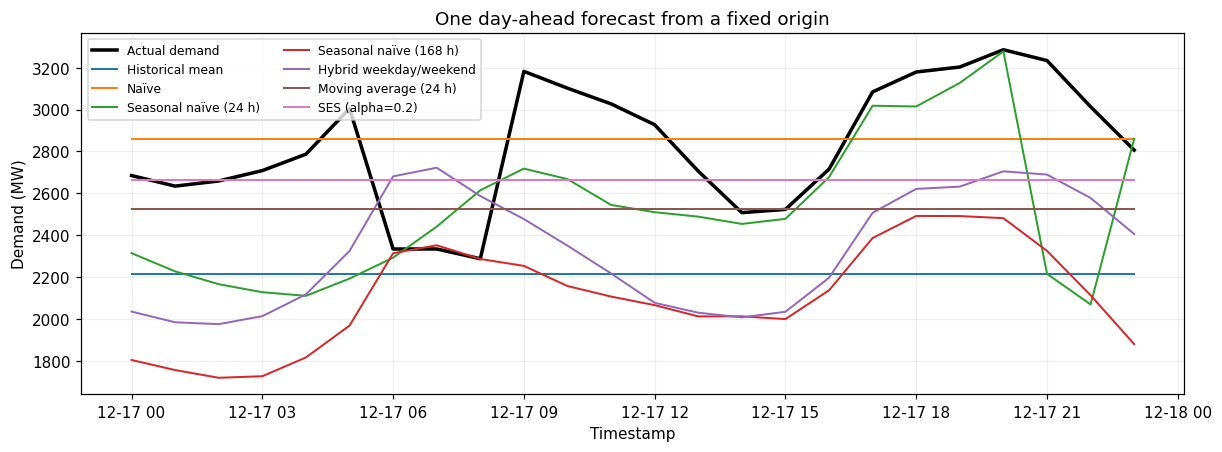

In [24]:
PRINCIPAL_MODELS = [
    "Naïve",
    "Seasonal naïve (24 h)",
    "Seasonal naïve (168 h)",
    "Hybrid weekday/weekend",
]
LEVEL_MODELS = [
    "Historical mean",
    "Moving average (24 h)",
    "SES (alpha=0.2)",
]


def plot_forecast_methods(actual, forecasts, model_names, title, ax=None):
    '''Plot actual demand and selected aligned forecast columns.'''
    if not actual.index.equals(forecasts.index):
        raise ValueError("actual and forecasts must have aligned indexes.")
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4))

    ax.plot(actual, color="black", linewidth=2.3, label="Actual demand")
    for model_name in model_names:
        ax.plot(forecasts[model_name], linewidth=1.3, label=model_name)
    ax.set(title=title, xlabel="Timestamp", ylabel="Demand (MW)")
    ax.grid(alpha=0.2)
    ax.legend(ncol=2, fontsize=8)
    return ax


fig, ax = plt.subplots(figsize=(11, 4))
plot_forecast_methods(
    day_ahead_actual,
    day_ahead_forecasts,
    list(day_ahead_forecasts.columns),
    "One day-ahead forecast from a fixed origin",
    ax=ax,
)
plt.show()


## 7. Rolling day-ahead forecasts over the complete test set

The rolling experiment begins at 23:00 on 30 September. It forecasts each day in the October–December test period. After each forecast day has passed, its actual observations become available. The origin moves forward by 24 hours, and the next forecast uses the updated history.

Using an observation after it has occurred is not data leakage. Leakage occurs when a forecast uses an observation that was still in the future at that forecast's origin.

### Task 6: implement the rolling-origin loop

Complete the `for` loop. For each day in `rolling_test_load`, create one 24-hour forecast table. Combine the daily tables, calculate errors over the full test period, and plot the selected December week.

In [25]:
def rolling_day_ahead_forecasts(complete_series, test_index):
    '''Issue one 24-hour forecast for every complete day in test_index.'''
    test_index = pd.DatetimeIndex(test_index)
    if test_index.empty or len(test_index) % 24 != 0:
        raise ValueError("test_index must contain one or more complete days.")
    if test_index[0].hour != 0 or test_index[-1].hour != 23:
        raise ValueError("test_index must start at 00:00 and end at 23:00.")

    expected_index = pd.date_range(
        test_index[0],
        test_index[-1],
        freq="h",
        name=test_index.name,
    )
    if not test_index.equals(expected_index):
        raise ValueError("test_index must be consecutive, sorted and unique.")

    forecast_parts = []
    origin_parts = []

    for day_start in test_index[::24]:
        origin = day_start - pd.Timedelta(hours=1)
        if origin not in complete_series.index:
            raise ValueError(f"Origin {origin} is not present in the series.")

        history = complete_series.loc[:origin]
        forecast_index = pd.date_range(
            day_start,
            periods=24,
            freq="h",
            name=complete_series.index.name,
        )
        daily_forecasts = build_benchmark_forecasts(history, forecast_index)
        forecast_parts.append(daily_forecasts)
        origin_parts.append(
            pd.Series(origin, index=forecast_index, name="forecast_origin")
        )

    forecasts = pd.concat(forecast_parts)
    forecast_origins = pd.concat(origin_parts)
    if not forecasts.index.equals(test_index):
        raise ValueError("Rolling forecasts must cover test_index exactly.")
    return forecasts, forecast_origins


rolling_forecasts, rolling_origin_by_timestamp = rolling_day_ahead_forecasts(
    aggregate_load_2007,
    rolling_test_load.index,
)
rolling_test_scores = score_forecasts(
    rolling_test_load,
    rolling_forecasts,
    rolling_training_load,
    m=168,
)
rolling_test_scores.round(3)


,RMSE (MW),MAPE (%),MASE (weekly SN)
Model,,,
Seasonal naïve (24 h),224.468,7.346,0.540
Hybrid weekday/weekend,246.248,8.017,0.587
SES (alpha=0.2),306.979,12.342,0.816
Moving average (24 h),312.871,12.197,0.840
Naïve,342.700,12.607,0.922
Seasonal naïve (168 h),363.382,12.122,0.892
Historical mean,411.475,16.396,1.097


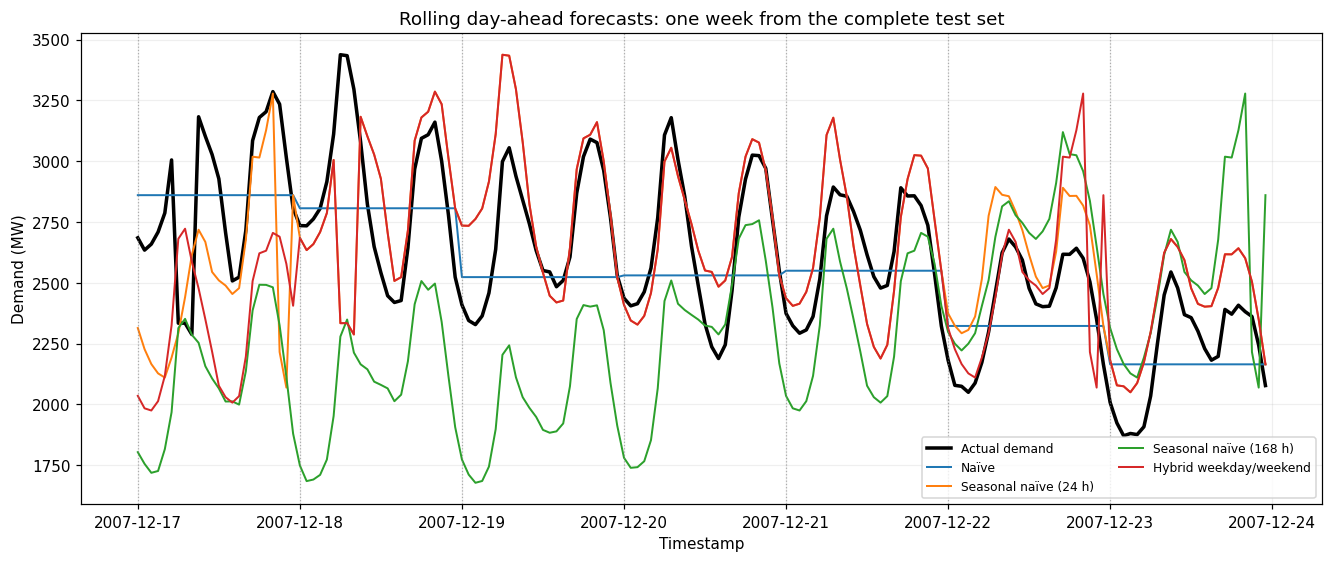

In [26]:
# Select one week for a readable illustration of the longer rolling test.
rolling_week_forecasts = rolling_forecasts.loc[test_week.index]

fig, ax = plt.subplots(figsize=(12, 5))
plot_forecast_methods(
    test_week,
    rolling_week_forecasts,
    PRINCIPAL_MODELS,
    "Rolling day-ahead forecasts: one week from the complete test set",
    ax=ax,
)
for day_start in pd.date_range(test_week.index[0], periods=7, freq="24h"):
    ax.axvline(day_start, color="0.5", linestyle=":", linewidth=0.8, alpha=0.6)
plt.show()


## 8. Fixed-horizon forecast for the full week

The final experiment uses the origin at 23:00 on 16 December and forecasts all 168 hours at once. No observation from the forecast week is used to update it.

### Task 7: construct and evaluate the fixed week-ahead forecasts

Call `build_benchmark_forecasts` with the fixed-origin training data and the full example-week index. Compare the results with the rolling forecasts for the same week.

In [27]:
fixed_week_forecasts = build_benchmark_forecasts(
    training_load,
    test_week.index,
)
fixed_week_scores = score_forecasts(
    test_week,
    fixed_week_forecasts,
    training_load,
    m=168,
)
fixed_week_scores.round(3)


,RMSE (MW),MAPE (%),MASE (weekly SN)
Model,,,
SES (alpha=0.2),338.941,11.190,0.961
Moving average (24 h),346.123,10.478,0.948
Seasonal naïve (24 h),392.137,11.021,1.004
Naïve,416.417,14.470,1.189
Hybrid weekday/weekend,429.952,14.208,1.289
Historical mean,519.197,15.521,1.480
Seasonal naïve (168 h),573.715,18.344,1.689


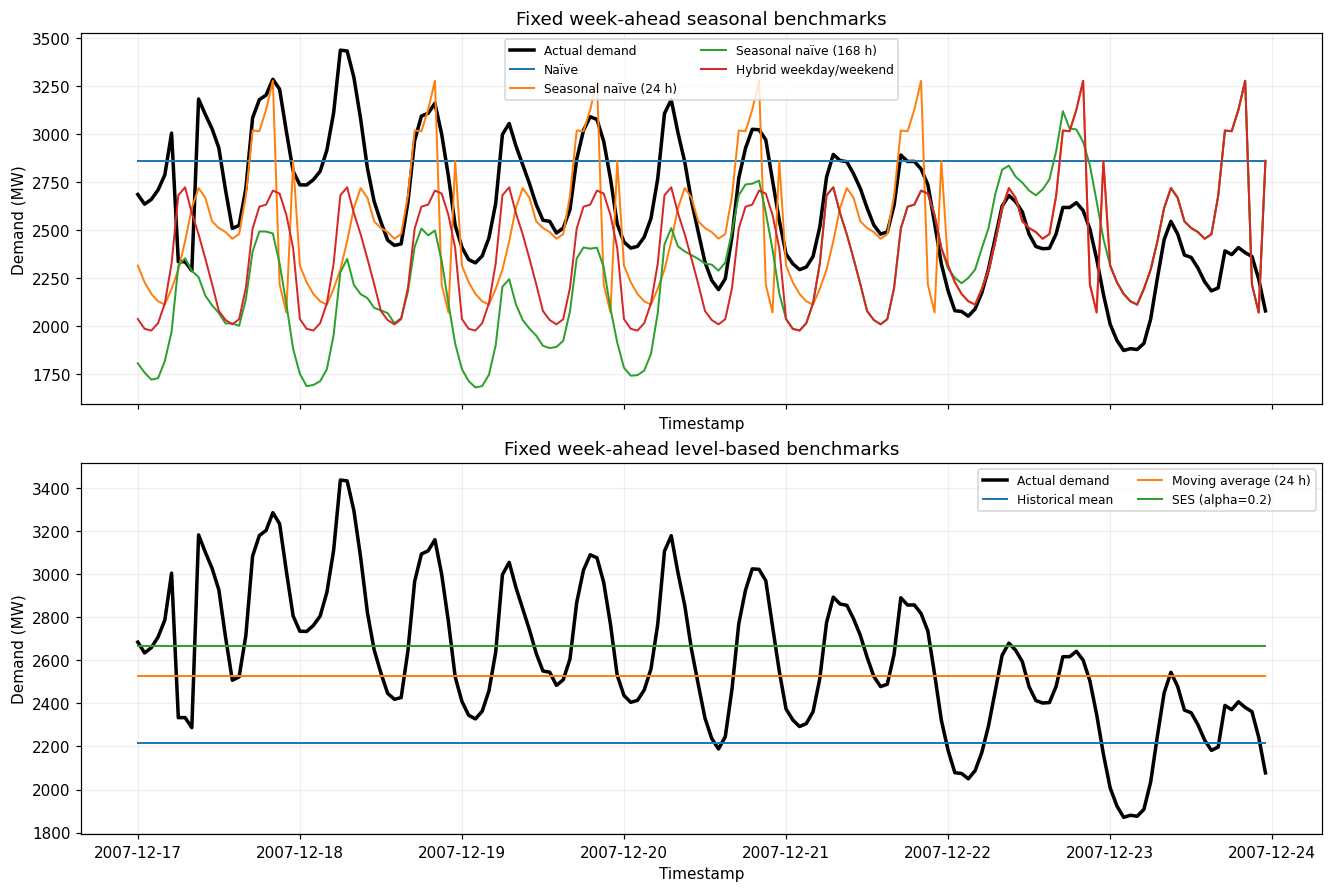

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plot_forecast_methods(
    test_week,
    fixed_week_forecasts,
    PRINCIPAL_MODELS,
    "Fixed week-ahead seasonal benchmarks",
    ax=axes[0],
)
plot_forecast_methods(
    test_week,
    fixed_week_forecasts,
    LEVEL_MODELS,
    "Fixed week-ahead level-based benchmarks",
    ax=axes[1],
)
plt.show()


### Rolling versus fixed-week performance

The rolling table above covers the full October–December test period. For a direct comparison, select the rolling forecasts for 17–23 December and score them against the same 168 observations used for the fixed week-ahead forecast.

Both tables use the weekly seasonal-naïve MASE scale calculated from `training_load`. The only difference is whether the forecast history is updated every 24 hours.

Rolling day-ahead                            \
                               RMSE (MW) MAPE (%) MASE (weekly SN)   
Model                                                                
Naïve                            272.967    8.640            0.784   
Seasonal naïve (24 h)            294.315    8.290            0.744   
SES (alpha=0.2)                  304.775   10.073            0.857   
Moving average (24 h)            308.609    9.900            0.863   
Hybrid weekday/weekend           333.637    9.261            0.843   
Historical mean                  516.770   15.416            1.470   
Seasonal naïve (168 h)           573.715   18.344            1.689   

                       Fixed week-ahead                            
                              RMSE (MW) MAPE (%) MASE (weekly SN)  
Model                                                              
Naïve                           416.417   14.470            1.189  
Seasonal naïve (24 h)           392.137   11.021            1.004  
SES (alpha=0.2)                 338.941   11.190            0.961  
Moving average (24 h)           346.123   10.478            0.948  
Hybrid weekday/weekend          429.952   14.208            1.289  
Historical mean                 519.197   15.521            1.480  
Seasonal naïve (168 h)          573.715   18.344            1.689

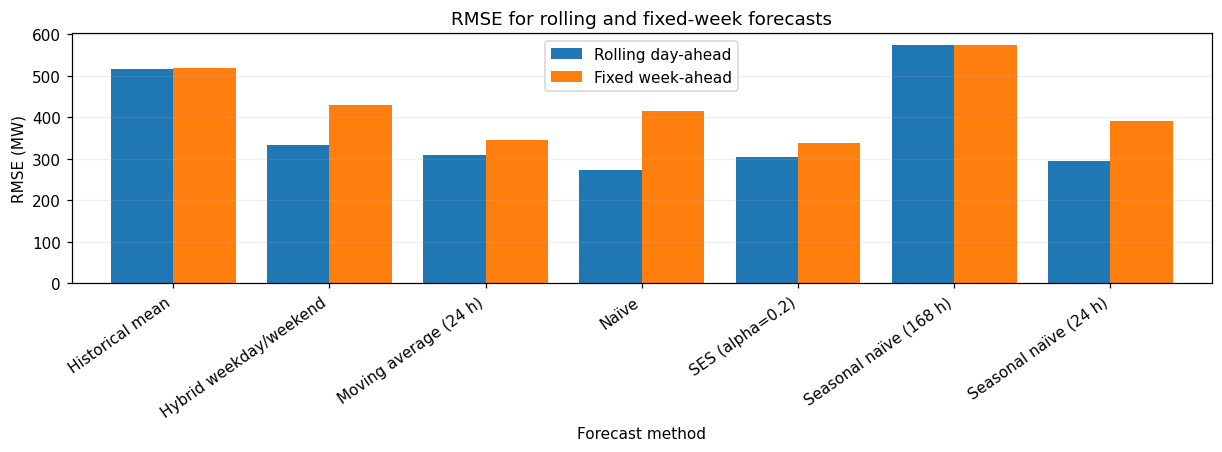

In [29]:
rolling_week_scores = score_forecasts(
    test_week,
    rolling_week_forecasts,
    training_load,
    m=168,
)

rolling_fixed_comparison = pd.concat(
    {
        "Rolling day-ahead": rolling_week_scores,
        "Fixed week-ahead": fixed_week_scores,
    },
    axis=1,
)
display(rolling_fixed_comparison.round(3))

rmse_comparison = pd.DataFrame(
    {
        "Rolling day-ahead": rolling_week_scores["RMSE (MW)"],
        "Fixed week-ahead": fixed_week_scores["RMSE (MW)"],
    }
)
ax = rmse_comparison.plot(kind="bar", figsize=(11, 4), width=0.8)
ax.set(
    title="RMSE for rolling and fixed-week forecasts",
    xlabel="Forecast method",
    ylabel="RMSE (MW)",
)
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=35, ha="right")
plt.show()


## 9. Interpretation questions

1. Which method performs best under each metric for the first 24-hour forecast?
2. What information becomes available at each rolling origin? Why is using it not leakage?
3. Which methods improve most when the forecast is updated daily instead of remaining fixed for a week?
4. Do RMSE, MAPE and MASE always rank the models in the same order?
5. Which methods represent daily seasonality, weekly seasonality or weekday/weekend differences?
6. Why are the moving-average and exponential-smoothing forecasts flat within each multi-step horizon?
7. Which benchmark defines the MASE denominator? What does MASE below one mean?
8. How could holidays, weather changes or unusual building operation affect seasonal benchmarks?
9. How would issuing the forecast at 11:00–12:00 on day $D-1$ change the information available for day $D$?

## 10. Optional extension — exponential smoothing at 10-minute resolution

High-frequency building measurements are often strongly autocorrelated: the next value is usually close to the current value. This can make one-step forecasts look very accurate even when the model gives a poor trajectory over the longer horizon needed for optimisation.

This extension uses five days of indoor-temperature measurements from an occupied UK house, sampled every 10 minutes. Use four days for training and forecast the final 24 hours with simple exponential smoothing (SES): $\ell_t=\alpha y_t+(1-\alpha)\ell_{t-1}$.

Compare two cases:

- **One-step ahead:** predict the next 10-minute value, observe the actual temperature, update the level and predict again.
- **Recursive multi-step:** make all 144 predictions from one origin without using later measurements. SES has no trend or seasonality, so feeding its forecast back into the model leaves the level unchanged. The predicted trajectory is therefore flat.

The recursive forecast is not numerically unstable. It may still move away from the measured temperature as the building warms or cools. Building optimisation usually needs a complete future trajectory from one origin, so good one-step accuracy alone is not enough.

Source: Hollick, F. and Wingfield, J. (2018), *Two periods of in-situ measurements from an occupied, semi-detached house in the UK*. https://doi.org/10.14324/000.ds.10087216

Missing indoor-temperature values before interpolation: 1


,RMSE [°C],Actual observations used after origin
One-step SES,0.056,143
Recursive multi-step SES,0.480,0


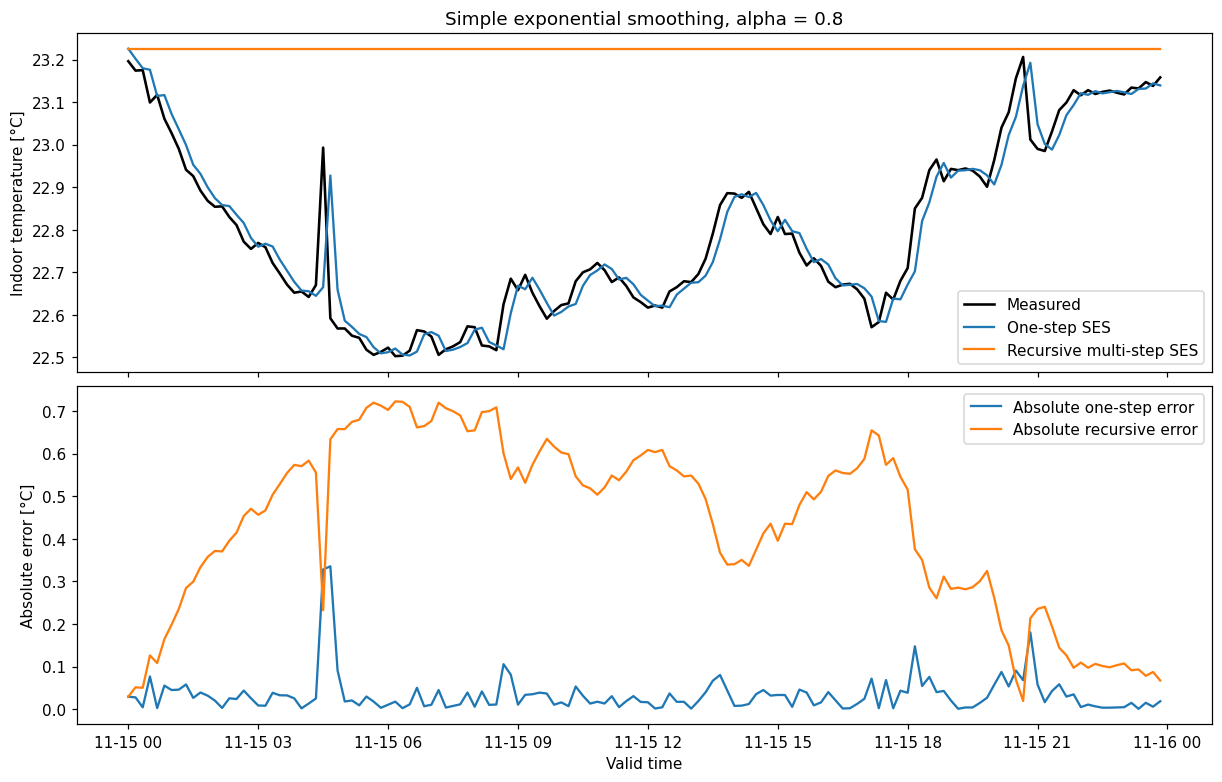

In [30]:
TEMPERATURE_PATH = (
    Path("data") / "tutorial_1_2" / "indoor_temperature_10min.csv"
)
temperature_data = pd.read_csv(
    TEMPERATURE_PATH,
    index_col="timestamp",
    parse_dates=True,
).sort_index()

expected_temperature_index = pd.date_range(
    temperature_data.index.min(),
    temperature_data.index.max(),
    freq="10min",
    name="timestamp",
)
if not temperature_data.index.equals(expected_temperature_index):
    raise ValueError("The optional temperature series must have a complete 10-minute index.")
if temperature_data.index.has_duplicates:
    raise ValueError("The optional temperature series contains duplicate timestamps.")

missing_temperature_values = int(
    temperature_data["indoor_temperature_c"].isna().sum()
)
print("Missing indoor-temperature values before interpolation:", missing_temperature_values)

# One isolated value is unavailable. Because this is a teaching extract,
# so time interpolation is used before the forecasting comparison.
indoor_temperature = temperature_data["indoor_temperature_c"].interpolate(
    method="time"
)
if indoor_temperature.isna().any():
    raise ValueError("Indoor temperature still contains missing values.")


def ses_one_step_and_recursive(series, forecast_start, alpha):
    # Return one-step-updated and fixed-origin recursive SES forecasts.
    if not 0 < alpha <= 1:
        raise ValueError("alpha must lie in (0, 1].")

    training = series.loc[series.index < forecast_start]
    test = series.loc[series.index >= forecast_start]
    if training.empty or test.empty:
        raise ValueError("Both training and test periods must contain observations.")

    level = float(training.iloc[0])
    for observation in training.iloc[1:]:
        level = alpha * float(observation) + (1 - alpha) * level

    # A fixed-origin multi-step SES forecast repeats the final estimated level.
    recursive = pd.Series(level, index=test.index, name="Recursive multi-step SES")

    # One-step evaluation updates the level with each newly observed test value.
    one_step_values = []
    updated_level = level
    for observation in test:
        one_step_values.append(updated_level)
        updated_level = alpha * float(observation) + (1 - alpha) * updated_level
    one_step = pd.Series(
        one_step_values,
        index=test.index,
        name="One-step SES",
    )
    return test, one_step, recursive


ses_alpha = 0.8
ses_forecast_start = indoor_temperature.index.min() + pd.Timedelta(days=4)
ses_actual, ses_one_step, ses_recursive = ses_one_step_and_recursive(
    indoor_temperature,
    forecast_start=ses_forecast_start,
    alpha=ses_alpha,
)

ses_comparison = pd.DataFrame(
    {
        "RMSE [°C]": {
            "One-step SES": np.sqrt(np.mean((ses_actual - ses_one_step) ** 2)),
            "Recursive multi-step SES": np.sqrt(
                np.mean((ses_actual - ses_recursive) ** 2)
            ),
        },
        "Actual observations used after origin": {
            "One-step SES": len(ses_actual) - 1,
            "Recursive multi-step SES": 0,
        },
    }
)
display(ses_comparison.round(3))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(ses_actual, color="black", linewidth=1.7, label="Measured")
axes[0].plot(ses_one_step, label="One-step SES")
axes[0].plot(ses_recursive, label="Recursive multi-step SES")
axes[0].set_ylabel("Indoor temperature [°C]")
axes[0].set_title(f"Simple exponential smoothing, alpha = {ses_alpha}")
axes[0].legend()

axes[1].plot(
    (ses_actual - ses_one_step).abs(),
    label="Absolute one-step error",
)
axes[1].plot(
    (ses_actual - ses_recursive).abs(),
    label="Absolute recursive error",
)
axes[1].set_ylabel("Absolute error [°C]")
axes[1].set_xlabel("Valid time")
axes[1].legend()
plt.show()


### Optional-extension interpretation

1. The one-step calculation receives a new temperature measurement every 10 minutes, so errors have little time to build up. The recursive forecast receives no new measurements after its origin.
2. SES without trend or seasonality predicts its final estimated level at every future step. Feeding this value back into the model leaves the level unchanged.
3. Each measured test temperature is available before the next one-step prediction. None of the test measurements is available when the full 24-hour trajectory is issued.
4. Useful additions include outdoor temperature, heating inputs, time-of-day effects, trend or seasonality, or an explicit thermal-state model. Evaluate the model over the same horizon used by the optimiser.